In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

: 

In [ ]:
import pandas as pd
from datetime import datetime
import keras 

import numpy as np
import os
import pandas as pd
import datetime
import math
import tensorflow as tf
from sklearn.metrics import RocCurveDisplay
from datetime import datetime

: 

In [4]:
#Para borrar archivos
# Clear output folder
import os

def remove_folder_contents(folder):
    for the_file in os.listdir(folder):
        file_path = os.path.join(folder, the_file)
        try:
            if os.path.isfile(file_path):
                os.unlink(file_path)
            elif os.path.isdir(file_path):
                remove_folder_contents(file_path)
                os.rmdir(file_path)
        except Exception as e:
            print(e)
folder_path = '/kaggle/working/'
remove_folder_contents(folder_path)
# os.rmdir(folder_path)
import git
git.Repo.clone_from('https://github.com/Mobile-Intelligence-Lab/ACID.git', '/kaggle/working/')

FileNotFoundError: [WinError 3] The system cannot find the path specified: '/kaggle/working/'

In [4]:
import os
csv_collection = []
for dirname, _, filenames in os.walk('/kaggle/input/csecicids2018'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        fullpath = os.path.join(dirname, filename)
        csv_collection.append(fullpath)
# Initialize an empty list to store the DataFrames
dfs = []

# Loop through the file names and read each file as a DataFrame
for csv in csv_collection:
    df1 = pd.read_parquet(csv).sample(frac=0.2, replace=False, random_state=42)
    dfs.append(df1)
df_new = pd.concat(dfs, ignore_index=True)
df_new.head()

/kaggle/input/csecicids2018/DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet
/kaggle/input/csecicids2018/DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet
/kaggle/input/csecicids2018/DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet
/kaggle/input/csecicids2018/Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet
/kaggle/input/csecicids2018/Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet
/kaggle/input/csecicids2018/Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet
/kaggle/input/csecicids2018/Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet
/kaggle/input/csecicids2018/DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet
/kaggle/input/csecicids2018/Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet
/kaggle/input/csecicids2018/Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,3566101,4,5,935,350.0,935,0,233.75,467.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,6,4376201,5,3,935,317.0,935,0,187.00,418.144714,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,6,4274185,4,5,935,323.0,935,0,233.75,467.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,6,4071155,5,3,935,370.0,935,0,187.00,418.144714,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,6,16006,3,4,345,935.0,345,0,115.00,199.185837,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DoS attacks-Hulk


In [5]:
df_new = df_new.sample(frac=0.05, replace=False, random_state=42)

In [6]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")
import json
import pandas as pd
import numpy as np
import pickle as pkl
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support as prf, accuracy_score
from pprint import pprint
from torch.autograd import Variable
from torch.utils.data import DataLoader
# from core.models.DeepClustering import DeepClustering
from core.utils.misc import extend_dataset
from core.utils import Dataset
from core.models.RandomForest import RandomForest

## Helper

In [7]:
def load_dataset(dataset_path):
    global categories
    if not os.path.exists(dataset_path):
        print(f"Dataset not found: {dataset_path}")
        sys.exit(1)
    df = df_new
    # df = pd.read_csv(dataset_path, index_col=False)
  
    train_test_split = .7
    msk = np.random.rand(len(df)) < train_test_split
    train_df = df[msk]
    test_df = df[~msk]

    return train_df, test_df, df


def save_model(rf, filename):
    with open(filename, 'wb') as f:
        pkl.dump(rf, f)


def load_model(filename):
    with open(filename, 'rb') as f:
        m = pkl.load(f)
    return m

def np_encoder(object):
    if isinstance(object, np.generic):
        return object.item()
class metrics(object):

    def __init__(self, tp=None, tn=None, fp=None, fn=None):
        super(metrics, self).__init__()

        self.tp, self.tn, self.fp, self.fn = tp, tn, fp, fn

        self.metrics = {}

    def accuracy(self):
        return (self.tp + self.tn) / (self.tp + self.tn + self.fp + self.fn)

    def detection_rate(self):
        return self.tp / (self.tp + self.fn)

    def false_alarm_rate(self):
        return self.fp / (self.fp + self.tn)

    def precision(self):
        return self.tp / (self.tp + self.fp)

    def f1(self):
        prec = self.precision()
        rec = self.detection_rate()
        return 0 if (prec + rec) == 0 else 2 * (prec * rec) / (prec + rec)

    def get_metrics(self):
        self.metrics = {"Acc": self.accuracy(), "DR/Recall": self.detection_rate(), "FAR": self.false_alarm_rate(),
                        "PRECISION": self.precision(), "F1 SCORE": self.f1()}
        return self.metrics

In [8]:
import torch
import torch.nn as nn
from torch.autograd import Variable


def get_rand(w, h, grad=True):
    t = torch.randn(w, h, requires_grad=grad)
    
    return nn.Parameter(Variable(t, requires_grad=grad))


class SubNet(nn.Module):
    def __init__(self, input_size, layers_dims=[50, 30]):
        super(SubNet, self).__init__()

        self.input_size = input_size
        self.layers_dims = [input_size + 0] + list(layers_dims) + [1]
        self.layers = []

        for i in range(1, len(self.layers_dims)):
            self.layers.append(nn.Linear(self.layers_dims[i-1], self.layers_dims[i]))
        self.net = nn.Sequential(*self.layers)

        self.kernel_weights = get_rand(1, input_size)

        self.encoder = None
        self.outputs = None

    def forward(self, x):
        for i in range(len(self.net) - 1):
            self = self.cuda()
            x = self.net[i](x).cuda()
            x = torch.tanh(x).cuda()
            x = x.cuda()
        x = self.net[-1](x).cuda()
        x = torch.sigmoid(x).cuda()
        x = x.cuda()

        self.outputs = x
        x = x.cuda()

        return x

In [9]:
import torch
import torch.nn as nn
from torch.autograd import Variable

import numpy as np


class Encoder(nn.Module):

    def __init__(self, layers_dims=(60, 40, 20)):
        super(Encoder, self).__init__()

        self.layers_dims = layers_dims
        self.input_shape = None
        self.layers = []
        self.net = None

        self.outputs = None

        sinWeights = []
        sinCoeffs = []

        for i in range(1, len(self.layers_dims)):
            self.layers.append(nn.Linear(self.layers_dims[i-1], self.layers_dims[i], bias=True))

            t = torch.randn(self.layers_dims[i - 1], 1, requires_grad=True).cuda()
          
            sinWeights.append(nn.Parameter(Variable(t, requires_grad=True)))

            t = torch.randn(1, 1, requires_grad=True).cuda()
          
            sinCoeffs.append(nn.Parameter(Variable(t, requires_grad=True)))

        self.sinWeights = sinWeights
        self.sinCoeffs = sinCoeffs

    def freeze(self):
        for param in self.parameters():
            param.requires_grad = False

    def unfreeze(self):
        for param in self.parameters():
            param.requires_grad = True

    def forward(self, x, save=True):

        if self.input_shape is None:
            self.input_shape = x.shape
            self.layers = [nn.Linear(self.input_shape[-1], self.layers_dims[0], bias=True)] + self.layers
            self.net = nn.Sequential(*self.layers)

            t = torch.randn(self.input_shape[-1], 1, requires_grad=True).cuda()
            self.sinWeights = [nn.Parameter(Variable(t, requires_grad=True))] + self.sinWeights
            

            t = torch.randn(1, 1, requires_grad=True).cuda()
            
            self.sinCoeffs = [nn.Parameter(Variable(t, requires_grad=True))] + self.sinCoeffs

            self.sinWeights = nn.ParameterList(self.sinWeights)
            self.sinCoeffs = nn.ParameterList(self.sinCoeffs)

        for i in range(len(self.net) - 1):
            self = self.cuda()
            x = x.cuda()
            x = self.net[i](x).cuda()
            
            self.sinCoeffs = self.sinCoeffs.cuda()
            self.sinWeights = self.sinWeights.cuda()
            x = self.sinCoeffs[i+1] * torch.sin(2 * np.pi * x * self.sinWeights[i+1].view(1, -1))
            x = x.cuda()
        x = self.net[-1](x).cuda()
        x = x.view(-1, self.layers_dims[-1]).cuda()

        if save:
            self.outputs = x
        x = x.cuda()

        return x

In [10]:
# from core.models.repr import Encoder
# from core.models.subnet import SubNet

import torch
import torch.nn as nn


class AdaptiveClustering(nn.Module):
    def __init__(self, encoder_dims=(60, 40, 20), kernel_size=3, n_kernels=None, subnet_dims=[50, 30]):
        super(AdaptiveClustering, self).__init__()

        assert n_kernels is not None, f"The number of kernels must be defined"
        assert n_kernels > 0, f"The number of kernels ({n_kernels}) must be greater than 0"
        assert kernel_size > 0, f"The dimensionality of kernels ({n_kernels}) must be greater than 0"

        self.kernel_size = kernel_size
        self.n_kernels = n_kernels
        self.subnet_dims = subnet_dims
        self.encoder_dims = list(encoder_dims) + [kernel_size]
        self.labels_ = None

        self.sub_nets = nn.ParameterList([])
        self.sub_nets_list = []

        self.add_sub_net()

        for i in range(len(self.sub_nets_list), self.n_kernels):
            self.add_sub_net()

    def add_sub_net(self):
        sub_net = SubNet(self.encoder_dims[-1], self.subnet_dims)
        sub_net.encoder = Encoder(layers_dims=self.encoder_dims)
        self.sub_nets_list.append(sub_net)
        self.sub_nets = nn.ModuleList(self.sub_nets_list)

    def remove_sub_net(self, idx):
        self.sub_nets_list.pop(idx)
        del self.sub_nets[idx]
        self.sub_nets = nn.ModuleList(self.sub_nets_list)

    def reset(self) -> None:
        pass

    @property
    def n_kernels_(self):
        return len(self.sub_nets)

    def loss(self):
        classification_loss = 0
        clustering_loss_close = 0
        clustering_loss_dist = 0
        labels = self.labels_

        for i in range(self.n_kernels_):
            idx = (labels == i).nonzero()
            idx_diff = (labels != i).nonzero()

            embeddings = self.sub_nets[i].encoder.outputs
            outputs = self.sub_nets[i].outputs

            targets = torch.zeros_like(outputs)
            targets[idx] = 1.
            classification_loss += ((outputs.squeeze() - targets.squeeze()) ** 2).mean()

            if len(idx) > 0:
                clustering_loss_close += ((embeddings[idx].view(-1, self.kernel_size) -
                                           self.sub_nets[i].kernel_weights) ** 2).mean()
                if len(idx_diff) > 0:
                    for j in list(set(labels[idx_diff])):
                        tmp_loss = ((self.sub_nets[i].kernel_weights.clone().detach() -
                                     self.sub_nets[j].kernel_weights) ** 2).mean()
                        clustering_loss_dist += torch.clamp(1 - tmp_loss, min=0)

        n_k_dist = (self.n_kernels_ - 1 if self.n_kernels_ > 1 else 1) * self.n_kernels_
        return classification_loss + (clustering_loss_close + clustering_loss_dist/n_k_dist) / self.n_kernels_

    def backward(self, losses: list):
        for loss in losses:
            loss.backward(retain_graph=True)

    def forward(self, x, labels=None):
#         device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        x = x.cuda()
        if self.training:
            assert labels is not None, "True labels must be provided during training."
        self.labels_ = labels

        outputs = []
        
        
        for i in range(self.n_kernels_):
            
            sub_net = self.sub_nets[i].cuda()
            x = x.cuda()
            embeddings = sub_net.encoder(x).cuda()
            x = x.cuda()
            output_probs = sub_net(embeddings)
            outputs.append(output_probs.view(embeddings.shape[0], 1, -1))
        
        outputs = torch.cat(tuple(outputs), 1)
        outputs = torch.softmax(outputs, dim=1).cuda()
        

        return outputs

In [11]:
import numpy as np
import torch

import os
import sys
from datetime import datetime

root_path = '/kaggle/working/'
sys.path.append(root_path)
class Dot(dict):
    """dot.notation access to dictionary attributes"""
    __getattr__ = dict.get
    __setattr__ = dict.__setitem__
    __delattr__ = dict.__delitem__


def log(msg, filename='output.txt'):
    if type(msg) in (list, tuple):
        for message in msg:
            log(message, filename)
    else:
        with open(root_path + '/' + filename, mode='a+') as f:
            f.write(f"[{str(datetime.now())}] {msg}\n")


def log_error(msg, filename='error.txt'):
    log(msg, filename)


def dist(x, y):
    if len(x.shape) == 1:
        x = x.view(-1, 1)
    if len(y.shape) == 1:
        y = y.view(-1, 1)

    n = x.size(0)
    m = y.size(0)
    d = x.size(1)

    x = x.unsqueeze(1).expand(n, m, d)
    y = y.unsqueeze(0).expand(n, m, d)

    d = torch.pow(x - y, 2).sum(2)
    return d


def extend_dataset(model, df, cats, label_tag):
    cols = df.columns.values.tolist()
    rf_features = []

    for i in range(model.kernel_size):
        cols.append(f'kernel_feature_{i}')
    cols.append(label_tag)

    print(f"Creating extended dataset...")
    for i, row in df.iterrows():
        rf_features_tmp = row.tolist()
        x = torch.FloatTensor(np.array([rf_features_tmp]))
        Trans_type = cats[i]
        with torch.no_grad():
            label = model(x)[0]
        label = label.max(dim=1).indices
        label = label[0].item()

        features = model.sub_nets[label].kernel_weights

        rf_features_tmp.extend(features.squeeze().tolist())
        rf_features_tmp.extend([Trans_type])

        rf_features.append(rf_features_tmp)
    print(f"Done creating extended dataset")

    return rf_features, cols

In [12]:
# Deep Clustering
def train(X, y, lr=1e-4):
    batch_size = 1024
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_ = AdaptiveClustering(encoder_dims=[500, 200, 50], n_kernels=len(categories), kernel_size=7)
    model_.train()

    if torch.cuda.is_available():
        model_ = model_.cuda()
        X = X.cuda()
        y = y.cuda()

    ds = Dataset(X, y)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

    n_epoch = 100
    optimizer = None

    for i in range(n_epoch):
        iteration_losses = []
        
        for x, labels_ in dl:
            x = x.cuda()
            labels_ = labels_.cuda()
    # اجرای مدل با داده‌های GPU
    
            model_ = model_.cuda()
            model_.zero_grad()
        
            _ = model_(x, labels_)
            
            if optimizer is None:
                optimizer = torch.optim.Adam(model_.parameters(), lr=lr)
            
            loss = model_.loss()
            loss_value = loss.item()
            
            iteration_losses.append(loss_value)
            
            loss.backward()
            optimizer.step()

        print(f"Iteration {i} | Loss {np.mean(iteration_losses)}")
        if np.mean(iteration_losses) < 1:
            print(f"Early stop triggered at: Iteration {i}")
            break

    model_.eval()
    return model_

# path

In [13]:
#path
root_path = '/kaggle/working/' 
dataset_path = root_path
extended_dataset_path = root_path + 'extended_dataset.csv'
results_path = './' + f'results'
if not os.path.exists(results_path):
    os.mkdir(results_path)
model_path = results_path + '/trained_model.pkl'
separator = "-"*50

In [14]:
if os.path.exists(extended_dataset_path):
    print('extended_dataset_path')

In [15]:
#Loading Dataset
# Dataset
# Loading dataset
print(separator)
print("Loading dataset...")
if os.path.exists(extended_dataset_path):
    train_df, test_df, df = load_dataset(extended_dataset_path)
else:
    train_df, test_df, df = load_dataset(dataset_path)
print("Done loading dataset")

--------------------------------------------------
Loading dataset...
Done loading dataset


In [16]:
train_df

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
679384,6,1702759,8,7,1148,1581.0,677,0,143.500000,228.129669,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
953091,6,188393,3,1,0,0.0,0,0,0.000000,0.000000,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1269630,6,199,3,1,31,0.0,31,0,10.333333,17.897858,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
287221,6,54087809,2,0,0,0.0,0,0,0.000000,0.000000,...,20,0.0,0.0,0.0,0.0,54100000.0,0.0,54100000.0,54100000.0,DDoS attacks-LOIC-HTTP
1124294,6,5701545,2,0,0,0.0,0,0,0.000000,0.000000,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1280792,6,2527736,8,8,1128,1581.0,661,0,141.000000,222.623322,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
582934,6,446179,9,6,520,3062.0,202,0,57.777779,85.151009,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
106341,6,50018,3,0,0,0.0,0,0,0.000000,0.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DoS attacks-Hulk
860636,6,10810,3,4,326,129.0,326,0,108.666664,188.216187,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Bot


In [17]:
#Loading
if os.path.exists(model_path + ".categories"):
    print(separator)
    print("Loading categories...")
    with open(model_path + ".categories", "r") as f:
        categories = json.load(f)
        print(f"categories loaded: {model_path}.categories")
    print("Done loading categories")
else:
    categories = list(set(pd.factorize(train_df['Label'])[1].values))

train_df_ = train_df.drop(['Label'], axis=1)

X = train_df_.values.tolist()
y = train_df['Label'].values.tolist()

X = torch.FloatTensor(np.array(X))

for i, l in enumerate(y):
    y[i] = categories.index(l)

y = torch.LongTensor(np.array(y))

cats = df['Label'].copy()
y_ = df['Label'].values
df.drop(['Label'], axis=1, inplace=True)

In [18]:
X


tensor([[6.0000e+00, 1.7028e+06, 8.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [6.0000e+00, 1.8839e+05, 3.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [6.0000e+00, 1.9900e+02, 3.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        ...,
        [6.0000e+00, 5.0018e+04, 3.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [6.0000e+00, 1.0810e+04, 3.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [6.0000e+00, 1.7132e+06, 3.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00]])

In [19]:
y

tensor([ 0,  0,  0,  ...,  9, 11, 10])

In [20]:

# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [21]:

print(torch.cuda.is_available())  # اگر True باشد، GPU در دسترس است
print(torch.cuda.current_device())  # شماره GPU فعلی
print(torch.cuda.get_device_name(torch.cuda.current_device()))  # نام GPU


True
0
Tesla T4


In [22]:
# !pip install torch==1.9.0+cu111 torchvision==0.10.0+cu111 torchaudio==0.9.0 -f https://download.pytorch.org/whl/cu111/torch_stable.html


In [23]:
print(torch.__version__)  # نسخه PyTorch
print(torch.version.cuda)  # نسخه CUDA


2.4.0
12.3


In [24]:
# pip uninstall torch torchvision
# pip install torch==1.x.x torchvision==0.x.x

In [25]:
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu123


In [26]:
y

tensor([ 0,  0,  0,  ...,  9, 11, 10])

In [27]:
model = train(X, y)

Iteration 0 | Loss 3.784825060678565
Iteration 1 | Loss 3.2944360504979673
Iteration 2 | Loss 2.7697882911433345
Iteration 3 | Loss 2.2754769117935845
Iteration 4 | Loss 1.8625858426094055
Iteration 5 | Loss 1.5570363350536511
Iteration 6 | Loss 1.3303384573563286
Iteration 7 | Loss 1.1671426840450452
Iteration 8 | Loss 1.055749193481777
Iteration 9 | Loss 0.984696766604548
Early stop triggered at: Iteration 9


In [28]:
if not os.path.exists(extended_dataset_path):
    rf_features, cols = extend_dataset(model, df, cats, label_tag='Label')

    del df
    del train_df
    del test_df

Creating extended dataset...
Done creating extended dataset


In [29]:
# #Training
# if not os.path.exists(model_path):
#     print("Training model...")
#     model = train(X, y)
#     print("Done training model")

# if not os.path.exists(extended_dataset_path):
#     rf_features, cols = extend_dataset(model, df, cats, label_tag='Label')

#     del df
#     del train_df
#     del test_df

In [30]:
if not os.path.exists(extended_dataset_path):
    print(f"Saving new dataset...")
    new_df = pd.DataFrame(data=rf_features, columns=cols)
    print(new_df['Label'].value_counts())
    new_df = new_df.explode('Label')
    new_df = new_df.drop_duplicates()
    new_df.to_csv(extended_dataset_path, index=False)
    print(f"Done saving new dataset: {extended_dataset_path}")
    train_test_split = .7
    msk = np.random.rand(len(new_df)) < train_test_split
    train_df = new_df[msk]
    test_df = new_df[~msk]
    df_ = train_df.drop(['Label'], axis=1)
    X = df_.values.tolist()
    y = train_df['Label'].values.tolist()
    for i, l in enumerate(y):
        y[i] = categories.index(l)

Saving new dataset...
Label
Benign                    53353
DDoS attacks-LOIC-HTTP     5753
DDOS attack-HOIC           1958
Bot                        1425
DoS attacks-Hulk           1394
Infilteration              1205
SSH-Bruteforce              970
DoS attacks-GoldenEye       417
DoS attacks-Slowloris        96
DDOS attack-LOIC-UDP         15
Brute Force -Web              7
Brute Force -XSS              2
Name: count, dtype: int64
Done saving new dataset: /kaggle/working/extended_dataset.csv


In [31]:
if not os.path.exists(model_path):
    print("Training Random Forest...")
    model.classifier = RandomForest(n_estimators=200)
    model.classifier.fit(X, y)
    print("Done training Random Forest")

    print("Saving model...")
    save_model(model, model_path)
    with open(model_path+".categories", "w") as f:
        json.dump(categories, f, default=np_encoder)
        print(f"Categories saved: {model_path}.categories")
    print("Done saving model")

Training Random Forest...
Done training Random Forest
Saving model...
Categories saved: ./results/trained_model.pkl.categories
Done saving model


In [32]:
if os.path.exists(model_path):
    print("Loading model...")
    model = load_model(model_path)
    print("Done loading model")

Loading model...
Done loading model


In [33]:
#Data Distr
print(f"Total data distribution: {len(test_df) + len(train_df)}")
total = {}
total['total'] = len(test_df) + len(train_df)
for cat in categories:
    total[cat] = len(test_df[test_df['Label'] == cat]) \
                   + len(train_df[train_df['Label'] == cat])
    print(f"\t{cat}: {total[cat]}")

print(f"Training data distribution: {len(train_df)} / {len(train_df) * 100 / total['total']}%")
for cat in categories:
    c = len(train_df[train_df['Label'] == cat])
    print(f"\t{cat}: {c} / {c*100 / total[cat]}%")
print(f"Testing data distribution: {len(test_df)} / {len(test_df) * 100 / total['total']}%")
for cat in categories:
    c = len(test_df[test_df['Label'] == cat])
    print(f"\t{cat}: {c} / {c * 100 / total[cat]}%")

Total data distribution: 66528
	Benign: 53287
	DDOS attack-LOIC-UDP: 15
	DDOS attack-HOIC: 1958
	DoS attacks-GoldenEye: 417
	Brute Force -Web: 7
	SSH-Bruteforce: 970
	DoS attacks-Slowloris: 96
	Infilteration: 1204
	Brute Force -XSS: 2
	DoS attacks-Hulk: 1394
	DDoS attacks-LOIC-HTTP: 5753
	Bot: 1425
Training data distribution: 46537 / 69.95099807599807%
	Benign: 37275 / 69.95139527464485%
	DDOS attack-LOIC-UDP: 12 / 80.0%
	DDOS attack-HOIC: 1345 / 68.69254341164454%
	DoS attacks-GoldenEye: 286 / 68.58513189448442%
	Brute Force -Web: 5 / 71.42857142857143%
	SSH-Bruteforce: 687 / 70.82474226804123%
	DoS attacks-Slowloris: 67 / 69.79166666666667%
	Infilteration: 833 / 69.18604651162791%
	Brute Force -XSS: 1 / 50.0%
	DoS attacks-Hulk: 972 / 69.72740315638451%
	DDoS attacks-LOIC-HTTP: 4060 / 70.57187554319485%
	Bot: 994 / 69.75438596491227%
Testing data distribution: 19991 / 30.049001924001924%
	Benign: 16012 / 30.04860472535515%
	DDOS attack-LOIC-UDP: 3 / 20.0%
	DDOS attack-HOIC: 613 / 31.3

In [34]:
test_df

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Idle Max,Idle Min,kernel_feature_0,kernel_feature_1,kernel_feature_2,kernel_feature_3,kernel_feature_4,kernel_feature_5,kernel_feature_6,Label
0,6.0,451.0,3.0,0.0,77.0,0.0,46.0,0.0,25.666666,23.459185,...,0.0,0.0,-0.214046,-0.997932,-1.437216,0.086363,-1.260989,-0.141102,-1.057769,Benign
1,6.0,1702759.0,8.0,7.0,1148.0,1581.0,677.0,0.0,143.500000,228.129669,...,0.0,0.0,-0.214046,-0.997932,-1.437216,0.086363,-1.260989,-0.141102,-1.057769,Benign
2,6.0,188393.0,3.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,-0.214046,-0.997932,-1.437216,0.086363,-1.260989,-0.141102,-1.057769,Benign
3,6.0,199.0,3.0,1.0,31.0,0.0,31.0,0.0,10.333333,17.897858,...,0.0,0.0,-0.214046,-0.997932,-1.437216,0.086363,-1.260989,-0.141102,-1.057769,Benign
6,17.0,262.0,1.0,1.0,59.0,75.0,59.0,59.0,59.000000,0.000000,...,0.0,0.0,-0.214046,-0.997932,-1.437216,0.086363,-1.260989,-0.141102,-1.057769,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66573,6.0,902.0,3.0,4.0,148.0,242.0,148.0,0.0,49.333332,85.447838,...,0.0,0.0,-0.214046,-0.997932,-1.437216,0.086363,-1.260989,-0.141102,-1.057769,Benign
66587,17.0,216.0,1.0,1.0,84.0,212.0,84.0,84.0,84.000000,0.000000,...,0.0,0.0,-0.214046,-0.997932,-1.437216,0.086363,-1.260989,-0.141102,-1.057769,Benign
66588,0.0,218772.0,5.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,-0.214046,-0.997932,-1.437216,0.086363,-1.260989,-0.141102,-1.057769,Benign
66590,6.0,446179.0,9.0,6.0,520.0,3062.0,202.0,0.0,57.777779,85.151009,...,0.0,0.0,-0.214046,-0.997932,-1.437216,0.086363,-1.260989,-0.141102,-1.057769,Benign


In [35]:
df = test_df.drop(['Label'], axis=1)
x = df.values.tolist()

y_hat = model.classifier.predict(x)
preds = []

for i in y_hat:
    preds.append(categories[i])

In [36]:
print("Creating confusion matrix...")

for i, category in enumerate(categories):
    test_df['Label'].replace(to_replace=category, value=i, inplace=True)
y_actual_ = test_df['Label'].values.tolist()
y_actual = []
for i in y_actual_:
    y_actual.append(categories[i])

print(f"Uniques actual: {list(set(y_actual))}")
print(f"Uniques preds: {list(set(preds))}")

y_actu = pd.Series(y_actual, name='Actual')
y_pred = pd.Series(preds, name='Predicted')

df_confusion = pd.crosstab(y_actu, y_pred, rownames=['Actual'], colnames=['Predicted'],
                           dropna=False, margins=False, normalize='index').round(4) * 100

df_confusion.to_csv(results_path + 'rf_confusion_matrix.csv')
print(f"Confusion matrix created and saved: {results_path}rf_confusion_matrix.csv")

Creating confusion matrix...
Uniques actual: ['Benign', 'DDOS attack-LOIC-UDP', 'DDOS attack-HOIC', 'DoS attacks-GoldenEye', 'Brute Force -Web', 'SSH-Bruteforce', 'DoS attacks-Slowloris', 'Infilteration', 'Brute Force -XSS', 'DoS attacks-Hulk', 'DDoS attacks-LOIC-HTTP', 'Bot']
Uniques preds: ['Benign', 'DDOS attack-LOIC-UDP', 'DDOS attack-HOIC', 'DoS attacks-GoldenEye', 'SSH-Bruteforce', 'DoS attacks-Slowloris', 'Infilteration', 'DoS attacks-Hulk', 'DDoS attacks-LOIC-HTTP', 'Bot']
Confusion matrix created and saved: ./resultsrf_confusion_matrix.csv


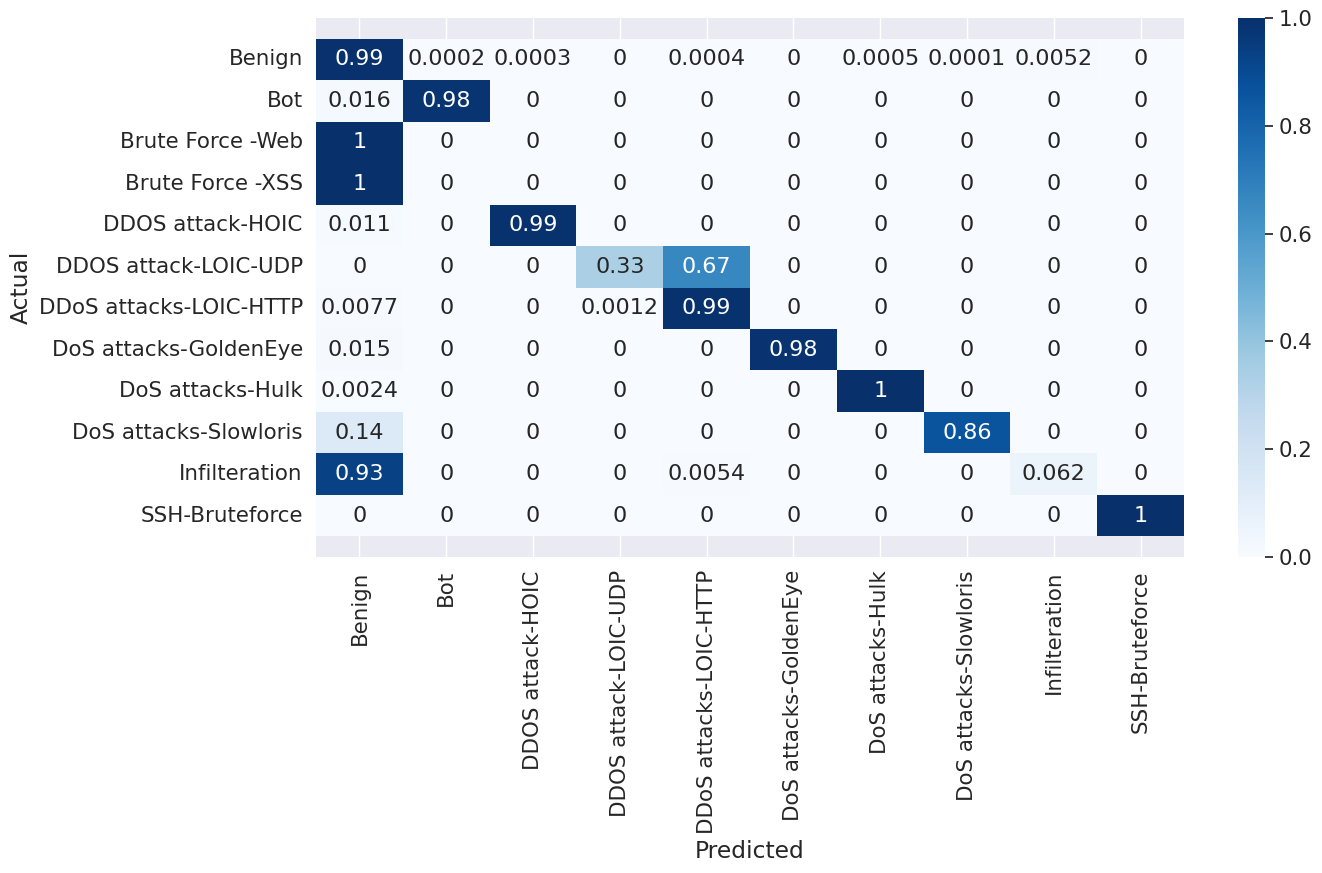

In [37]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

df_cm =  pd.crosstab(y_actu, y_pred, rownames=['Actual'], colnames=['Predicted'],
                           dropna=False, margins=False, normalize='index').round(4)
plt.figure(figsize = (14,7))
sns.set(font_scale=1.4)
sns.heatmap(df_cm, cmap="Blues", annot=True, annot_kws={"size": 16})
b, t = plt.ylim()
b += 0.5
t -= 0.5
plt.ylim(b, t)
plt.show()

In [38]:
print("Calculating feature importance scores...")
importances = model.classifier.cls.feature_importances_
indices = np.argsort(importances)[-50:][::-1]  # -50 #most important features
cols = test_df.columns.values.tolist()

feature_importances_list = []
for f in range(len(indices)):
    feature_importances_list.append([indices[f], cols[indices[f]], importances[indices[f]]])

with open(results_path + "rf_feature_importance_scores.pkl", "wb") as f:
    pkl.dump(feature_importances_list, f)
    print(f"Feature importance scores saved: {results_path}rf_feature_importance_scores.pkl")

    print("")
    print("15 most important features")
    pprint(feature_importances_list[:15])
    print("Sum 15:", np.sum(importances[indices[:15]]))
    print("")

Calculating feature importance scores...
Feature importance scores saved: ./resultsrf_feature_importance_scores.pkl

15 most important features
[[65, 'Init Fwd Win Bytes', 0.054684377739293175],
 [4, 'Fwd Packets Length Total', 0.037421187060166644],
 [34, 'Fwd Header Length', 0.03574233141351375],
 [6, 'Fwd Packet Length Max', 0.03292987195809992],
 [19, 'Flow IAT Min', 0.031779171406836705],
 [68, 'Fwd Seg Size Min', 0.030424894924267958],
 [62, 'Subflow Fwd Bytes', 0.029750057281185245],
 [24, 'Fwd IAT Min', 0.027728515385986995],
 [18, 'Flow IAT Max', 0.027650047115019335],
 [1, 'Flow Duration', 0.0272030257365132],
 [53, 'Avg Fwd Segment Size', 0.026615104739503],
 [8, 'Fwd Packet Length Mean', 0.02661075467011927],
 [20, 'Fwd IAT Total', 0.026187501833021647],
 [23, 'Fwd IAT Max', 0.02588094096706308],
 [16, 'Flow IAT Mean', 0.0256244744254884]]
Sum 15: 0.46623225665607826



In [39]:
# Performance metrics


print("Calculating performance metrics...")
cnf_matrix = confusion_matrix(y_actual_, y_hat)
_fp = cnf_matrix.sum(axis=0) - np.diag(cnf_matrix)
_fn = cnf_matrix.sum(axis=1) - np.diag(cnf_matrix)
_tp = np.diag(cnf_matrix)
_tn = cnf_matrix.sum() - (_fp + _fn + _tp)

_fp = _fp.astype(float)
_fn = _fn.astype(float)
_tp = _tp.astype(float)
_tn = _tn.astype(float)

_fp = np.mean(_fp)
_fn = np.mean(_fn)
_tp = np.mean(_tp)
_tn = np.mean(_tn)

metrics_handler = metrics(tp=_tp, tn=_tn, fp=_fp, fn=_fn)
metrics_data = metrics_handler.get_metrics()

accuracy = accuracy_score(y_actual_, y_hat)
precision, recall, f_score, support = prf(y_actual_, y_hat, average='weighted')
print("Accuracy : {:0.4f}, Precision : {:0.4f}, Recall : {:0.4f}, F-score : {:0.4f}, FAR: {:0.4f}"
                                                      .format(accuracy, precision,
                                                              recall, f_score, metrics_data["FAR"]))

with open(results_path + "metrics_handler.pkl", "wb") as f:
    pkl.dump(metrics_handler, f)
    print(f"Performance metrics saved: {results_path}metrics_handler.pkl")

print(separator)

Calculating performance metrics...
Accuracy : 0.9752, Precision : 0.9650, Recall : 0.9752, F-score : 0.9692, FAR: 0.0023
Performance metrics saved: ./resultsmetrics_handler.pkl
--------------------------------------------------
